##Step2: Data Collection

###Import Necessary Libraries

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import confusion_matrix,classification_report,roc_curve,roc_auc_score,accuracy_score

###Import Dataset

In [ ]:
loan_prediction_data = pd.read_csv("loan_prediction.csv")

In [ ]:
loan_prediction_data

,Unnamed: 0,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,LP002305,Female,No,0,Graduate,No,4547,0.0,115.0,360.0,1.0,Semiurban,1
1,1,LP001715,Male,Yes,3+,Not Graduate,Yes,5703,0.0,130.0,360.0,1.0,Rural,1
2,2,LP002086,Female,Yes,0,Graduate,No,4333,2451.0,110.0,360.0,1.0,Urban,0
3,3,LP001136,Male,Yes,0,Not Graduate,Yes,4695,0.0,96.0,NaN,1.0,Urban,1
4,4,LP002529,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.0,1.0,Semiurban,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
486,486,LP002103,NaN,Yes,1,Graduate,Yes,9833,1833.0,182.0,180.0,1.0,Urban,1
487,487,LP001790,Female,No,1,Graduate,No,3812,0.0,112.0,360.0,1.0,Rural,1
488,488,LP001401,Male,Yes,1,Graduate,No,14583,0.0,185.0,180.0,1.0,Rural,1
489,489,LP002893,Male,No,0,Graduate,No,1836,33837.0,90.0,360.0,1.0,Urban,0


##Step3: Data Understanding

###Perform Initial Investigation

In [ ]:
loan_prediction_data.shape

(491, 14)

In [ ]:
loan_prediction_data.isna().sum()

,0
Unnamed: 0,0
Loan_ID,0
Gender,10
Married,1
Dependents,9
Education,0
Self_Employed,29
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,16


In [ ]:
loan_prediction_data.dtypes

,0
Unnamed: 0,int64
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64


In [ ]:
loan_prediction_data.describe()

,Unnamed: 0,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
count,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000
mean,245.000000,0.753564,5401.189409,1589.730998,144.395112,341.792261,0.861507,0.698574
std,141.883755,1.015373,6419.427177,2919.320624,84.956932,66.138118,0.345769,0.459345
min,0.000000,0.000000,150.000000,0.000000,17.000000,12.000000,0.000000,0.000000
25%,122.500000,0.000000,2923.500000,0.000000,100.000000,360.000000,1.000000,0.000000
50%,245.000000,0.000000,3865.000000,1229.000000,126.000000,360.000000,1.000000,1.000000
75%,367.500000,1.000000,5705.500000,2251.500000,160.000000,360.000000,1.000000,1.000000
max,490.000000,3.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000,1.000000


##Step4: Data Preparation

####Since More 5-8% of data contains null, so let's perform some data preprocessing

In [ ]:
loan_prediction_data["Gender"].fillna(
    loan_prediction_data["Gender"].mode()[0],
    inplace=True
)

/tmp/ipykernel_825/1831229179.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_prediction_data["Gender"].fillna(


In [ ]:
loan_prediction_data["LoanAmount"].fillna(
    loan_prediction_data["LoanAmount"].median(),
    inplace = True
)

/tmp/ipykernel_825/921391311.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_prediction_data["LoanAmount"].fillna(


In [ ]:
loan_prediction_data["Loan_Amount_Term"].fillna(
    loan_prediction_data["Loan_Amount_Term"].median(),
    inplace=True
)

/tmp/ipykernel_825/2031101694.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_prediction_data["Loan_Amount_Term"].fillna(


In [ ]:
loan_prediction_data["Married"].value_counts()

,count
Married,
Yes,324
No,166


In [ ]:
loan_prediction_data["Dependents"].value_counts()

,count
Dependents,
0,276
1,85
2,78
3+,43


In [ ]:
loan_prediction_data["Self_Employed"].value_counts()

,count
Self_Employed,
No,398
Yes,64


In [ ]:
loan_prediction_data["Credit_History"].value_counts()

,count
Credit_History,
1.0,380
0.0,68


In [ ]:
loan_prediction_data['Married'].fillna(
    loan_prediction_data["Married"].mode()[0],
    inplace=True
)

/tmp/ipykernel_825/3360130092.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_prediction_data['Married'].fillna(


In [ ]:
loan_prediction_data['Dependents'].fillna(
loan_prediction_data["Dependents"].mode()[0],
inplace=True
)

/tmp/ipykernel_825/1297161323.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_prediction_data['Dependents'].fillna(


In [ ]:
loan_prediction_data['Self_Employed'].fillna(
    loan_prediction_data["Self_Employed"].mode()[0],
    inplace=True
)

/tmp/ipykernel_825/2554069018.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_prediction_data['Self_Employed'].fillna(


In [ ]:
loan_prediction_data['Credit_History'].mode()

,Credit_History
0,1.0


,0
Unnamed: 0,int64
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64


In [ ]:
print(loan_prediction_data['Credit_History'].unique())

[1. 0.]


In [ ]:
loan_prediction_data['Credit_History'].fillna(
    loan_prediction_data['Credit_History'].mode()[0],
    inplace=True
)

/tmp/ipykernel_825/651179676.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_prediction_data['Credit_History'].fillna(


In [ ]:
loan_prediction_data.isna().sum()

,0
Unnamed: 0,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0


In [ ]:
loan_prediction_data.dtypes

,0
Unnamed: 0,int64
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64


###Coversion of Object to float

In [ ]:
loan_prediction_data["Dependents"] = loan_prediction_data["Dependents"].replace(
    {
        '0': 0,
        '1': 1,
        '2': 2,
        '3+': 3
    }
)

loan_prediction_data["Dependents"] = loan_prediction_data['Dependents'].astype(int)

/tmp/ipykernel_825/2844515250.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan_prediction_data["Dependents"] = loan_prediction_data["Dependents"].replace(


In [ ]:
loan_prediction_data.dtypes

,0
Unnamed: 0,int64
Loan_ID,object
Gender,object
Married,object
Dependents,int64
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64


In [ ]:
loan_prediction_data.head()

,Unnamed: 0,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,LP002305,Female,No,0,Graduate,No,4547,0.0,115.0,360.0,1.0,Semiurban,1
1,1,LP001715,Male,Yes,3,Not Graduate,Yes,5703,0.0,130.0,360.0,1.0,Rural,1
2,2,LP002086,Female,Yes,0,Graduate,No,4333,2451.0,110.0,360.0,1.0,Urban,0
3,3,LP001136,Male,Yes,0,Not Graduate,Yes,4695,0.0,96.0,360.0,1.0,Urban,1
4,4,LP002529,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.0,1.0,Semiurban,1


####Encoding Of Numeric columns


In [ ]:
loan_prediction_data['Gender'] = loan_prediction_data['Gender'].map(
    {
        'Female': 0,
        'Male': 1
    }
)

In [ ]:
loan_prediction_data['Married'] = loan_prediction_data['Married'].map(
    {
        'No':0,
        'Yes':1
    }
)

In [ ]:
loan_prediction_data['Education'] = loan_prediction_data['Education'].map(
    {
        'Not Graduate':0,
        'Graduate':1
    }
)

In [ ]:
loan_prediction_data['Self_Employed'] = loan_prediction_data['Self_Employed'].map(
    {
        'No': 0,
        'Yes': 1
    }
)

In [ ]:
loan_prediction_data= pd.get_dummies(
    data = loan_prediction_data,
    columns=['Property_Area'],
    drop_first=True
)

In [ ]:
loan_prediction_data = loan_prediction_data.astype(
    {
        'Property_Area_Semiurban':int,
        'Property_Area_Urban':int
    }
)

In [ ]:
loan_prediction_data.head()

,Unnamed: 0,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,0,LP002305,0,0,0,1,0,4547,0.0,115.0,360.0,1.0,1,1,0
1,1,LP001715,1,1,3,0,1,5703,0.0,130.0,360.0,1.0,1,0,0
2,2,LP002086,0,1,0,1,0,4333,2451.0,110.0,360.0,1.0,0,0,1
3,3,LP001136,1,1,0,0,1,4695,0.0,96.0,360.0,1.0,1,0,1
4,4,LP002529,1,1,2,1,0,6700,1750.0,230.0,300.0,1.0,1,1,0


In [ ]:
loan_prediction_data.dtypes

,0
Unnamed: 0,int64
Loan_ID,object
Gender,int64
Married,int64
Dependents,int64
Education,int64
Self_Employed,int64
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64


####Separation of input and outps

In [ ]:
X = loan_prediction_data.drop(labels=['Unnamed: 0','Loan_ID','Loan_Status'],axis=1)
X

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Semiurban,Property_Area_Urban
0,0,0,0,1,0,4547,0.0,115.0,360.0,1.0,1,0
1,1,1,3,0,1,5703,0.0,130.0,360.0,1.0,0,0
2,0,1,0,1,0,4333,2451.0,110.0,360.0,1.0,0,1
3,1,1,0,0,1,4695,0.0,96.0,360.0,1.0,0,1
4,1,1,2,1,0,6700,1750.0,230.0,300.0,1.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
486,1,1,1,1,1,9833,1833.0,182.0,180.0,1.0,0,1
487,0,0,1,1,0,3812,0.0,112.0,360.0,1.0,0,0
488,1,1,1,1,0,14583,0.0,185.0,180.0,1.0,0,0
489,1,0,0,1,0,1836,33837.0,90.0,360.0,1.0,0,1


In [ ]:
y=loan_prediction_data['Loan_Status']
y

,Loan_Status
0,1
1,1
2,0
3,1
4,1
...,...
486,1
487,1
488,1
489,0


##Step5: Model Building

####Train Test Split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=13,
    shuffle=True
)

In [ ]:
rf_model = RandomForestClassifier(n_estimators=50,criterion='gini',max_depth=5)

In [ ]:
dt_model = DecisionTreeClassifier(criterion='entropy',max_depth=6)

In [ ]:
ada_model = AdaBoostClassifier(n_estimators=50)

####Grid Search CV for Random Forest

In [ ]:
grid_search = GridSearchCV(estimator=rf_model,
                           param_grid={'n_estimators':[50,75,100],
                                       'criterion':['gini','entropy'],
                                       'max_depth': [5,6,7,8,9]})
grid_search.fit(X_train,y_train)

GridSearchCV(estimator=RandomForestClassifier(criterion='entropy', max_depth=8,
                                              n_estimators=150),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 6, 7, 8, 9],
                         'n_estimators': [50, 75, 100]})

In [ ]:
grid_search.best_params_

{'criterion': 'gini', 'max_depth': 5, 'n_estimators': 50}

In [ ]:
grid_search.best_score_

np.float64(0.8314832846478415)

####GridSearchCV for Decision Tree


In [ ]:
grid_search_dt = GridSearchCV(estimator=dt_model,param_grid={
                                                  'criterion':['gini','entropy'],
                                                  'max_depth':[5,6,7,8,9,10]
})
grid_search_dt.fit(X_train,y_train)

GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 6, 7, 8, 9, 10]})

In [ ]:
print(grid_search_dt.best_params_)

{'criterion': 'entropy', 'max_depth': 6}


In [ ]:
print(grid_search_dt.best_score_)

0.7959104186952289


####GridSearchCV for AdaBoost

In [ ]:
grid_search_ada = GridSearchCV(estimator=ada_model,param_grid={'n_estimators':[50,60,70,80,90]})

grid_search_ada.fit(X_train,y_train)

GridSearchCV(estimator=AdaBoostClassifier(),
             param_grid={'n_estimators': [50, 60, 70, 80, 90]})

In [ ]:
print(grid_search_ada.best_params_)

{'n_estimators': 50}


In [ ]:
print(grid_search_ada.best_score_)

0.8264199935086012


##Step6: Model Training

In [ ]:
dt_model.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=6)

In [ ]:
rf_model.fit(X_train,y_train)

RandomForestClassifier(max_depth=5, n_estimators=50)

In [ ]:
ada_model.fit(X_train,y_train)

AdaBoostClassifier()

##Step 7: Model Testing

####Decision Tree Testing

In [ ]:
dt_pred_train = dt_model.predict(X_train)

In [ ]:
dt_pred_test = dt_model.predict(X_test)

####Random Forest Testing

In [ ]:
y_pred_train = rf_model.predict(X_train)

In [ ]:
y_pred_test = rf_model.predict(X_test)

####AdaBoost Testing

In [ ]:
ada_pred_train = ada_model.predict(X_train)

In [ ]:
ada_pred_test = ada_model.predict(X_test)

##Step 8: Model Evaluation

####Decision Tree Evaluation

In [ ]:
print(confusion_matrix(y_train,dt_pred_train))

[[ 71  43]
 [ 10 268]]


In [ ]:
print(classification_report(y_train,dt_pred_train))

              precision    recall  f1-score   support

           0       0.88      0.62      0.73       114
           1       0.86      0.96      0.91       278

    accuracy                           0.86       392
   macro avg       0.87      0.79      0.82       392
weighted avg       0.87      0.86      0.86       392



auc score: 0.9017259876309478


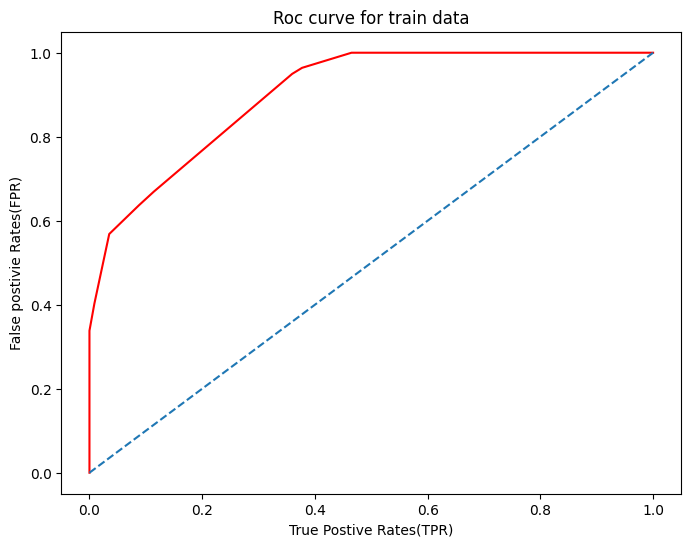

In [ ]:
y_prob = dt_model.predict_proba(X_train)[:,1]
fpr, tpr,threshold  = roc_curve(y_train,y_prob)
auc_score = roc_auc_score(y_train,y_prob)
print('auc score:',auc_score)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='red')
plt.plot([0,1],[0,1],linestyle='--')
plt.title('Roc curve for train data')
plt.xlabel('True Postive Rates(TPR)')
plt.ylabel('False postivie Rates(FPR)')
plt.show()



####Test Data Evaluation

In [ ]:
print(confusion_matrix(y_test,dt_pred_test))

[[11 23]
 [ 9 56]]


In [ ]:
print(classification_report(y_test,dt_pred_test))

              precision    recall  f1-score   support

           0       0.55      0.32      0.41        34
           1       0.71      0.86      0.78        65

    accuracy                           0.68        99
   macro avg       0.63      0.59      0.59        99
weighted avg       0.65      0.68      0.65        99



auc_score: 0.5925339366515837


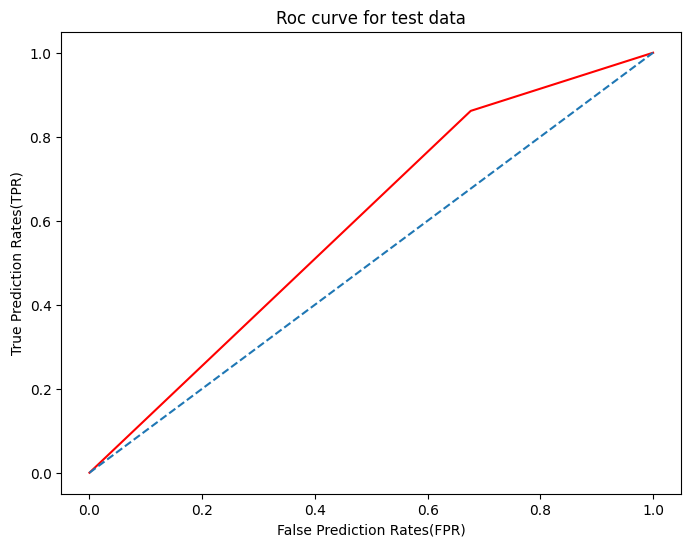

In [ ]:
y_prob = dt_model.predict_proba(X_test)[:,1]
fpr,tpr,threshold = roc_curve(y_test,dt_pred_test)
auc_score = roc_auc_score(y_test,dt_pred_test)
print('auc_score:',auc_score)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='red')
plt.plot([0,1],[0,1],linestyle="--")
plt.title('Roc curve for test data')
plt.xlabel('False Prediction Rates(FPR)')
plt.ylabel('True Prediction Rates(TPR)')
plt.show()

####Random Forest Evaluation

In [ ]:
print(confusion_matrix(y_train,y_pred_train))

[[ 53  61]
 [  2 276]]


In [ ]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.96      0.46      0.63       114
           1       0.82      0.99      0.90       278

    accuracy                           0.84       392
   macro avg       0.89      0.73      0.76       392
weighted avg       0.86      0.84      0.82       392



In [ ]:
accuracy_score(y_train,y_pred_train)

0.8392857142857143

auc score: 0.9519437081913417


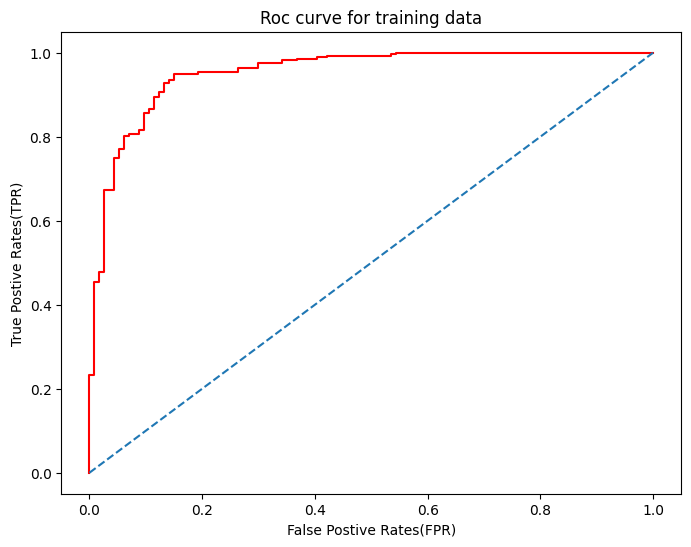

In [ ]:
y_prob = rf_model.predict_proba(X_train)[:,1]
fpr,tpr,threshold = roc_curve(y_train,y_prob)
auc_score = roc_auc_score(y_train,y_prob)
print("auc score:",auc_score)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='red')
plt.plot([0,1],[0,1],linestyle="--")
plt.title("Roc curve for training data")
plt.xlabel("False Postive Rates(FPR)")
plt.ylabel("True Postive Rates(TPR)")
plt.show()

####Test Data Evaluation

In [ ]:
print(confusion_matrix(y_test,y_pred_test))


[[11 23]
 [ 2 63]]


In [ ]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.85      0.32      0.47        34
           1       0.73      0.97      0.83        65

    accuracy                           0.75        99
   macro avg       0.79      0.65      0.65        99
weighted avg       0.77      0.75      0.71        99



auc score: 0.6567873303167421


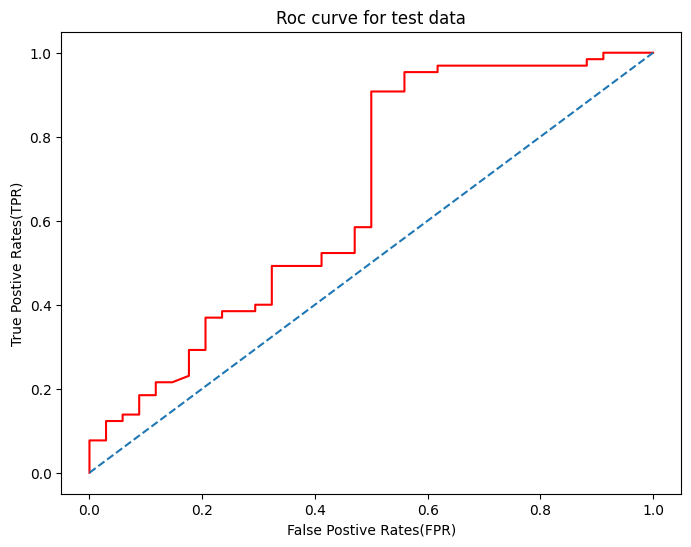

In [ ]:
y_prob = rf_model.predict_proba(X_test)[:,1]
fpr,tpr,threshold = roc_curve(y_test,y_prob)
auc_score = roc_auc_score(y_test,y_prob)
print("auc score:",auc_score)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='red')
plt.plot([0,1],[0,1],linestyle="--")
plt.title('Roc curve for test data')
plt.xlabel('False Postive Rates(FPR)')
plt.ylabel('True Postive Rates(TPR)')
plt.show()

####AdaBoost Evaluation

In [ ]:
print(confusion_matrix(y_train,ada_pred_train))

[[ 56  58]
 [  3 275]]


In [ ]:
print(classification_report(y_train,ada_pred_train))

              precision    recall  f1-score   support

           0       0.95      0.49      0.65       114
           1       0.83      0.99      0.90       278

    accuracy                           0.84       392
   macro avg       0.89      0.74      0.77       392
weighted avg       0.86      0.84      0.83       392



auc score: 0.8802694686356178


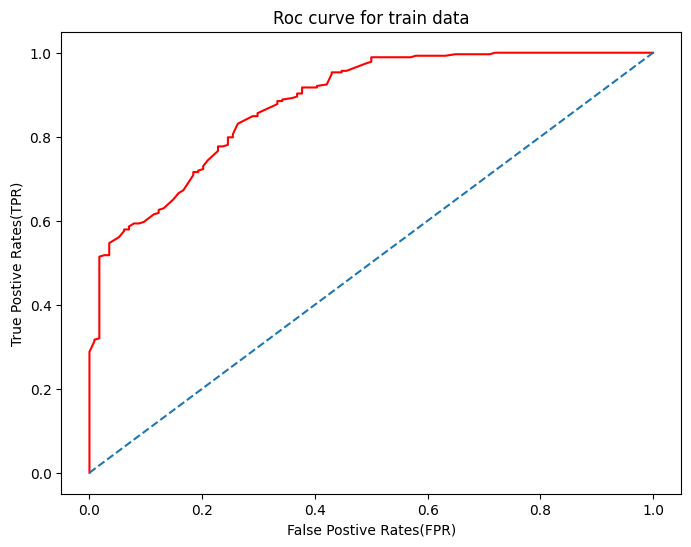

In [ ]:
y_prob = ada_model.predict_proba(X_train)[:,1]
fpr,tpr,threshold = roc_curve(y_train,y_prob)
auc_score = roc_auc_score(y_train,y_prob)
print('auc score:',auc_score)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='red')
plt.plot([0,1],[0,1],linestyle='--')
plt.title('Roc curve for train data')
plt.xlabel('False Postive Rates(FPR)')
plt.ylabel('True Postive Rates(TPR)')
plt.show()

####Test Data Evaluation

In [ ]:
print(confusion_matrix(y_test,ada_pred_test))

[[11 23]
 [ 2 63]]


In [ ]:
print(classification_report(y_test,ada_pred_test))

              precision    recall  f1-score   support

           0       0.85      0.32      0.47        34
           1       0.73      0.97      0.83        65

    accuracy                           0.75        99
   macro avg       0.79      0.65      0.65        99
weighted avg       0.77      0.75      0.71        99



auc score: 0.6733031674208144


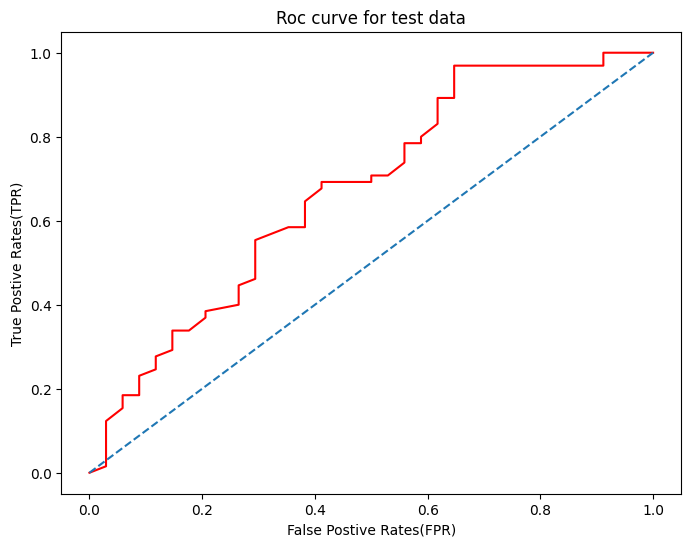

In [ ]:
y_prob = ada_model.predict_proba(X_test)[:,1]
fpr,tpr,threshold = roc_curve(y_test,y_prob)
auc_score = roc_auc_score(y_test,y_prob)
print('auc score:',auc_score)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='red')
plt.plot([0,1],[0,1],linestyle='--')
plt.title('Roc curve for test data')
plt.xlabel('False Postive Rates(FPR)')
plt.ylabel('True Postive Rates(TPR)')
plt.show()